
# 02_09 — Boost model performance with Gradient Boosting and LightGBM

In this notebook, you'll explore how **Gradient Boosting** improves model performance by building trees sequentially, where each new tree corrects the mistakes of the previous one.  
You’ll also experiment with **LightGBM**, a modern and efficient gradient boosting library optimized for speed and scalability.


## Import libraries

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

import lightgbm as lgb

## Generate the dataset

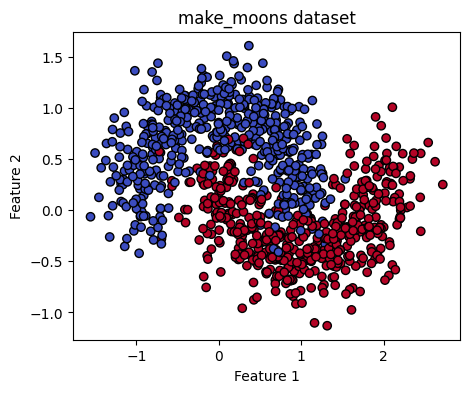

In [2]:

X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title("make_moons dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Split data into training and test sets

In [3]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Train a Gradient Boosting model

In [4]:

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.3f}")


Gradient Boosting Accuracy: 0.953


## Visualize Gradient Boosting decision boundary

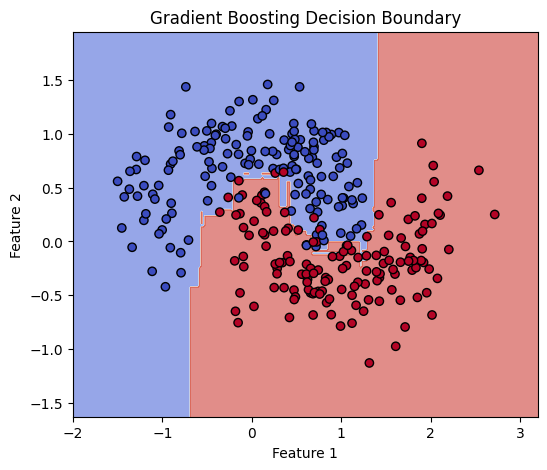

In [5]:

def plot_decision_boundary(model, X, y, ax, title):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(gb, X_test, y_test, ax, "Gradient Boosting Decision Boundary")
plt.show()


## Train a LightGBM model

In [6]:

lgbm = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm.fit(X_train, y_train)

y_pred_lgb = lgbm.predict(X_test)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"LightGBM Accuracy: {accuracy_lgb:.3f}")


[LightGBM] [Info] Number of positive: 356, number of negative: 344
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508571 -> initscore=0.034289
[LightGBM] [Info] Start training from score 0.034289
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Visualize LightGBM decision boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


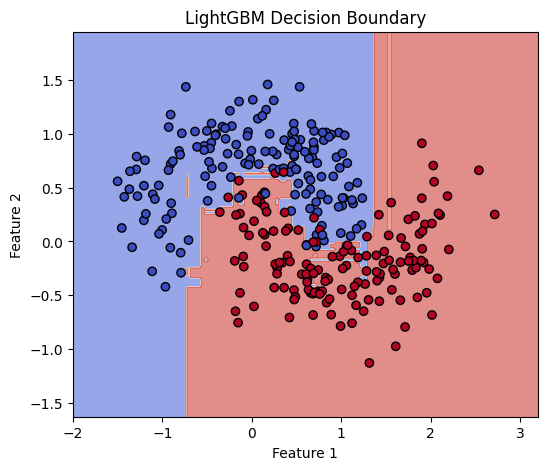

In [7]:

fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(lgbm, X_test, y_test, ax, "LightGBM Decision Boundary")
plt.show()


## Compare model performances

In [8]:

print(f"Gradient Boosting Accuracy: {accuracy_gb:.3f}")
print(f"LightGBM Accuracy: {accuracy_lgb:.3f}")

results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'LightGBM'],
    'Accuracy': [accuracy_gb, accuracy_lgb]
})
results


Gradient Boosting Accuracy: 0.953
LightGBM Accuracy: 0.943


,Model,Accuracy
0,Gradient Boosting,0.953333
1,LightGBM,0.943333
